In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rohini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
df = pd.read_excel("Resume data tas03.xlsx")
df.head()

,ID,Resume_str,Resume_html,Category,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 159,Unnamed: 160,Unnamed: 161,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.shape

(3446, 169)

In [5]:
df.shape
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       ...
       'Unnamed: 159', 'Unnamed: 160', 'Unnamed: 161', 'Unnamed: 162',
       'Unnamed: 163', 'Unnamed: 164', 'Unnamed: 165', 'Unnamed: 166',
       'Unnamed: 167', 'Unnamed: 168'],
      dtype='str', length=169)

In [6]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [7]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='str')

In [8]:
df = df[['ID','Resume_str','Category']]
df.head()

,ID,Resume_str,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,33176873,HR DIRECTOR Summary Over 2...,HR
3,27018550,HR SPECIALIST Summary Dedica...,HR
4,17812897,HR MANAGER Skill Highlights ...,HR


In [1]:
print("Jupyter working correctly")

Jupyter working correctly


In [4]:
def clean_text(text):
    
    text = str(text)        # convert to string
    text = text.lower()
    
    text = re.sub(r'[^a-zA-Z ]',' ', text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [5]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [6]:
df = pd.read_excel("Resume data tas03.xlsx")

In [7]:
df.head()

,ID,Resume_str,Resume_html,Category,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 159,Unnamed: 160,Unnamed: 161,Unnamed: 162,Unnamed: 163,Unnamed: 164,Unnamed: 165,Unnamed: 166,Unnamed: 167,Unnamed: 168
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.dropna(subset=['Resume_str'])

In [9]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Rohini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def clean_text(text):
    
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

In [11]:
df['clean_resume'] = df['Resume_str'].apply(clean_text) 

In [12]:
df = df.dropna(subset=['Resume_str'])

In [13]:
df['Resume_str'].isnull().sum()

np.int64(0)

In [14]:
df = df.dropna(subset=['Resume_str'])

df['clean_resume'] = df['Resume_str'].apply(clean_text)

In [15]:
job_description = """
Looking for a data scientist with experience in python, machine learning,
data analysis, statistics, pandas, numpy, scikit-learn, data visualization,
deep learning, and SQL.
"""

In [16]:
job_clean = clean_text(job_description)

In [17]:
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(df['clean_resume'])

job_vector = tfidf.transform([job_clean])

NameError: name 'TfidfVectorizer' is not defined

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [19]:
tfidf = TfidfVectorizer()

resume_vectors = tfidf.fit_transform(df['clean_resume'])
job_vector = tfidf.transform([job_description])

In [20]:
!pip install scikit-learn

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

resume_vectors = tfidf.fit_transform(df['clean_resume'])
job_vector = tfidf.transform([job_description])

In [23]:
from sklearn.metrics.pairwise import cosine_similarity

In [24]:
similarity = cosine_similarity(job_vector, resume_vectors)

In [25]:
scores = similarity.flatten()

In [26]:
df['match_score'] = scores

In [27]:
ranked_resumes = df.sort_values(by='match_score', ascending=False)

In [28]:
ranked_resumes[['ID','Category','match_score']].head(10)

,ID,Category,match_score
1405,18448085,AUTOMOBILE,0.253394
1263,21156767,CONSULTANT,0.247503
2687,12011623,ENGINEERING,0.228901
949,62994611,AGRICULTURE,0.223814
3115,34953092,BANKING,0.135486
1369,42156237,DIGITAL-MEDIA,0.135107
1084,12351749,SALES,0.132679
333,18067556,NaN,0.131119
1187,30863060,CONSULTANT,0.126591
1136,24610685,SALES,0.125943


In [29]:
ranked_resumes.to_csv("ranked_resumes.csv", index=False)

In [30]:
skills = [
    'python','machine learning','sql','excel','deep learning',
    'data analysis','pandas','numpy','tableau','power bi',
    'statistics','nlp','data visualization','tensorflow'
]

In [31]:
def extract_skills(text):
    
    found_skills = []
    
    for skill in skills:
        if skill in text:
            found_skills.append(skill)
    
    return found_skills

In [32]:
df['skills_found'] = df['clean_resume'].apply(extract_skills)

In [33]:
df[['ID','skills_found']].head()

,ID,skills_found
0,16852973,"[data analysis, statistics]"
1,22323967,[]
2,33176873,[excel]
3,27018550,[excel]
4,17812897,[excel]


In [34]:
job_skills = extract_skills(job_description)

print(job_skills)

['python', 'machine learning', 'deep learning', 'data analysis', 'pandas', 'numpy', 'statistics', 'data visualization']


In [35]:
def skill_gap(resume_skills):
    
    missing = list(set(job_skills) - set(resume_skills))
    
    return missing

In [36]:
df['missing_skills'] = df['skills_found'].apply(skill_gap)

In [37]:
ranked_resumes[['ID','match_score','skills_found','missing_skills']].head(10)

KeyError: "['skills_found', 'missing_skills'] not in index"

In [38]:
ranked_resumes[['ID','match_score','skills_found','missing_skills']].head()

KeyError: "['skills_found', 'missing_skills'] not in index"

In [39]:
skills = [
'python','machine learning','sql','excel','deep learning',
'data analysis','pandas','numpy','tableau','power bi',
'statistics','nlp'
]

In [40]:
def extract_skills(text):

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [41]:
df['skills_found'] = df['clean_resume'].apply(extract_skills)

In [42]:
df[['ID','skills_found']].head()

,ID,skills_found
0,16852973,"[data analysis, statistics]"
1,22323967,[]
2,33176873,[excel]
3,27018550,[excel]
4,17812897,[excel]


In [43]:
job_skills = extract_skills(job_description)
print(job_skills)

['python', 'machine learning', 'deep learning', 'data analysis', 'pandas', 'numpy', 'statistics']


In [44]:
def skill_gap(resume_skills):

    missing = list(set(job_skills) - set(resume_skills))

    return missing

In [45]:
df['missing_skills'] = df['skills_found'].apply(skill_gap)

In [46]:
ranked_resumes = df.sort_values(by='match_score', ascending=False)

ranked_resumes[['ID','match_score','skills_found','missing_skills']].head(10)

,ID,match_score,skills_found,missing_skills
1405,18448085,0.253394,"[python, sql, excel, data analysis, pandas, nu...","[machine learning, deep learning]"
1263,21156767,0.247503,"[python, machine learning, sql, data analysis]","[numpy, pandas, statistics, deep learning]"
2687,12011623,0.228901,"[python, machine learning, sql, excel, data an...","[numpy, deep learning]"
949,62994611,0.223814,"[python, sql, excel, pandas, tableau]","[machine learning, statistics, numpy, deep lea..."
3115,34953092,0.135486,"[python, machine learning, sql]","[statistics, numpy, pandas, deep learning, dat..."
1369,42156237,0.135107,"[python, sql, excel, tableau, power bi]","[machine learning, statistics, numpy, pandas, ..."
1084,12351749,0.132679,"[machine learning, excel, data analysis, table...","[python, numpy, pandas, deep learning]"
333,18067556,0.131119,"[python, sql, excel, data analysis, tableau]","[machine learning, statistics, numpy, pandas, ..."
1187,30863060,0.126591,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."
1136,24610685,0.125943,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."


In [47]:
top_candidates = ranked_resumes[['ID','match_score','skills_found','missing_skills']].head(10)
top_candidates

,ID,match_score,skills_found,missing_skills
1405,18448085,0.253394,"[python, sql, excel, data analysis, pandas, nu...","[machine learning, deep learning]"
1263,21156767,0.247503,"[python, machine learning, sql, data analysis]","[numpy, pandas, statistics, deep learning]"
2687,12011623,0.228901,"[python, machine learning, sql, excel, data an...","[numpy, deep learning]"
949,62994611,0.223814,"[python, sql, excel, pandas, tableau]","[machine learning, statistics, numpy, deep lea..."
3115,34953092,0.135486,"[python, machine learning, sql]","[statistics, numpy, pandas, deep learning, dat..."
1369,42156237,0.135107,"[python, sql, excel, tableau, power bi]","[machine learning, statistics, numpy, pandas, ..."
1084,12351749,0.132679,"[machine learning, excel, data analysis, table...","[python, numpy, pandas, deep learning]"
333,18067556,0.131119,"[python, sql, excel, data analysis, tableau]","[machine learning, statistics, numpy, pandas, ..."
1187,30863060,0.126591,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."
1136,24610685,0.125943,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."


In [48]:
import matplotlib.pyplot as plt

In [49]:
!pip install matplotlib

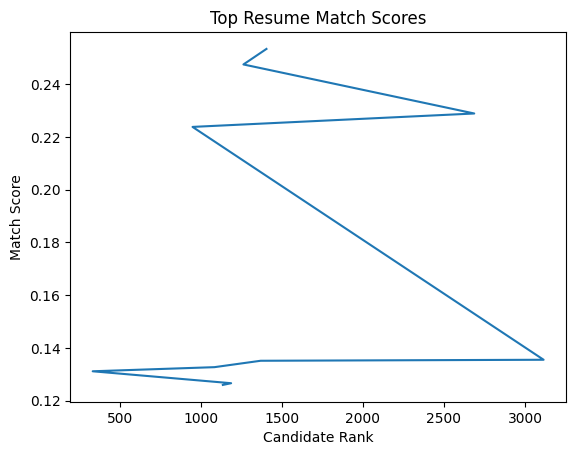

In [50]:
top_scores = ranked_resumes['match_score'].head(10)

plt.figure()
plt.plot(top_scores)
plt.xlabel("Candidate Rank")
plt.ylabel("Match Score")
plt.title("Top Resume Match Scores")
plt.show()

In [51]:
final_results = ranked_resumes[['ID','Category','match_score','skills_found','missing_skills']].head(10)

final_results

,ID,Category,match_score,skills_found,missing_skills
1405,18448085,AUTOMOBILE,0.253394,"[python, sql, excel, data analysis, pandas, nu...","[machine learning, deep learning]"
1263,21156767,CONSULTANT,0.247503,"[python, machine learning, sql, data analysis]","[numpy, pandas, statistics, deep learning]"
2687,12011623,ENGINEERING,0.228901,"[python, machine learning, sql, excel, data an...","[numpy, deep learning]"
949,62994611,AGRICULTURE,0.223814,"[python, sql, excel, pandas, tableau]","[machine learning, statistics, numpy, deep lea..."
3115,34953092,BANKING,0.135486,"[python, machine learning, sql]","[statistics, numpy, pandas, deep learning, dat..."
1369,42156237,DIGITAL-MEDIA,0.135107,"[python, sql, excel, tableau, power bi]","[machine learning, statistics, numpy, pandas, ..."
1084,12351749,SALES,0.132679,"[machine learning, excel, data analysis, table...","[python, numpy, pandas, deep learning]"
333,18067556,NaN,0.131119,"[python, sql, excel, data analysis, tableau]","[machine learning, statistics, numpy, pandas, ..."
1187,30863060,CONSULTANT,0.126591,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."
1136,24610685,SALES,0.125943,"[sql, excel, tableau]","[machine learning, statistics, numpy, pandas, ..."


In [52]:
ranked_resumes.to_csv("resume_screening_results.csv", index=False)